<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. What are 3 areas in industry where computer vision is currently being used?

Healthcare: X-ray & MRI.

Self-driving cars: Tesla

Manufacturing: detecting deflects in products during production

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

after training your model on a train set, overfittign happens when the model learns the dataset too well and starts to memorize it. It may perform extremely well (perhaps even with 100% accuracy) on the train set, byt its performance on unseen data will be poor

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

*Data Augmentation*: creating modified versions of training data helps the model generalize better instead of memorizing examples.

*Dropout*: randomly turning off some neurons during training reduces the model’s dependence on specific neurons.

*Early Stopping*: stopping training when validation performance stops improving can prevent the model from overfitting.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

done!

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
train_data = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor(), target_transform=None)

100%|██████████| 9.91M/9.91M [00:31<00:00, 312kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 90.2kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 259kB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [9]:
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor(), target_transform=None)

In [10]:
len(train_data), len(test_data)

(60000, 10000)

In [17]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [18]:
class_to_indx = train_data.class_to_idx
class_to_indx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [19]:
img, label = train_data[0]
img, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [20]:
class_names[label]

'5 - five'

In [21]:
img.shape

torch.Size([1, 28, 28])

## 6. Visualize at least 5 different samples of the MNIST training dataset.

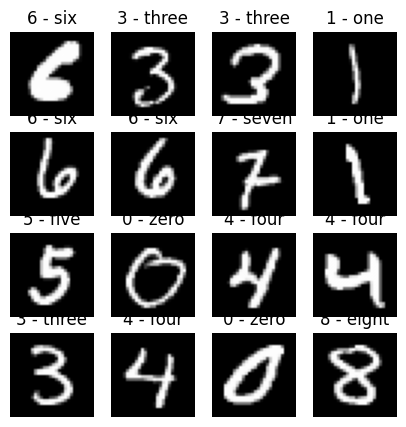

In [24]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(5, 5))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [27]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)

test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)

In [28]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x21ec0b417c0>,
 <torch.utils.data.dataloader.DataLoader at 0x21ec07d0500>)

In [29]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

In [30]:
len(train_data) / BATCH_SIZE, len(test_data) / BATCH_SIZE

(1875.0, 312.5)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [42]:
class MNIST(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=4, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*5*5, out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [43]:
torch.manual_seed(42)
model_2 = MNIST(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device=device)

In [44]:
img.shape

torch.Size([1, 28, 28])

In [45]:
x = torch.randn(1, 1, 28, 28)

x = model_2.conv_block1(x)
print(x.shape)

x = model_2.conv_block2(x)
print(x.shape)

torch.Size([1, 10, 13, 13])
torch.Size([1, 10, 5, 5])


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

gpu not available!

In [49]:
loss_func = nn.CrossEntropyLoss()

def accuracy_fn(y_pred, y_true):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

optimizer = torch.optim.SGD(params=model_2.parameters(), lr= 0.1)

In [52]:
epochs = 5

for epoch in range(epochs):
    train_loss , train_acc = 0, 0
    model_2.train()

    for (x,y) in (train_dataloader):
        x, y = x.to(device), y.to(device)

        y_pred = model_2(x)

        loss = loss_func(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_pred.argmax(dim=1), y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    print(f"train loss = {train_loss}, train accuracy = {train_acc}")


    test_loss, test_acc = 0, 0
    model_2.eval()

    with torch.inference_mode():
        for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)

            test_pred = model_2(x)

            y_test_pred = test_pred.argmax(dim=1)
            test_loss += loss_func(test_pred, y).item()
            test_acc += accuracy_fn(y_test_pred, y_true=y)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        print(f"test loss = {test_loss}, test accuracy = {test_acc}")

train loss = 0.09090544288118059, train accuracy = 97.18833333333333
test loss = 0.09192385274274185, test accuracy = 97.00479233226837
train loss = 0.06592339267212277, train accuracy = 98.03166666666667
test loss = 0.0460318281822399, test accuracy = 98.40255591054313
train loss = 0.0549551481131309, train accuracy = 98.24
test loss = 0.05229863502808992, test accuracy = 98.30271565495208
train loss = 0.04814663672315267, train accuracy = 98.53166666666667
test loss = 0.04292057036660138, test accuracy = 98.58226837060703
train loss = 0.04346759510077148, train accuracy = 98.69
test loss = 0.05472938577903393, test accuracy = 98.09305111821087


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

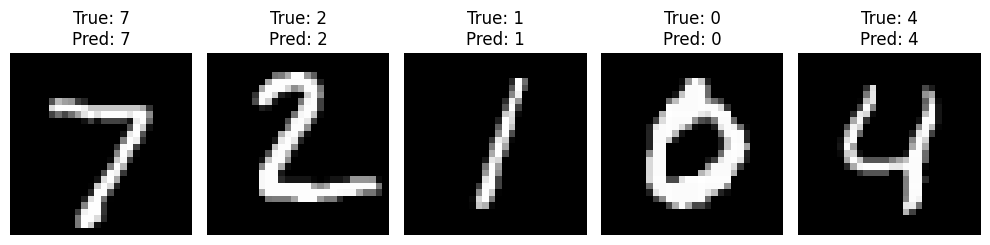

In [53]:
fig = plt.figure(figsize=(10, 5))

model_2.eval()
with torch.inference_mode():

    for i in range(5):
        img, label = test_data[i]

        # add batch dimension
        image_for_model = img.unsqueeze(0).to(device)

        # prediction
        logits = model_2(image_for_model)
        pred_label = logits.argmax(dim=1).item()

        # plot
        plt.subplot(1, 5, i + 1)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.title(f"True: {label}\nPred: {pred_label}")
        plt.axis("off")

plt.tight_layout()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

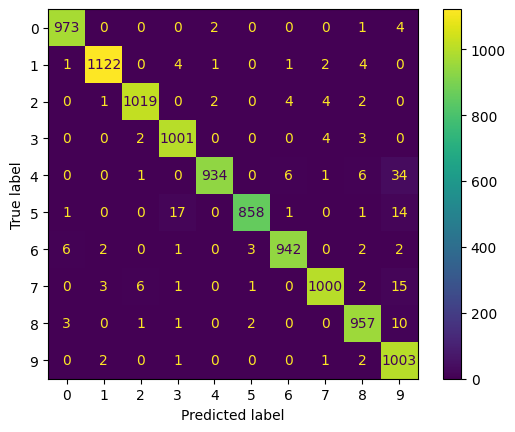

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_preds = []
y_true = []

model_2.eval()
with torch.inference_mode():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)

        logits = model_2(x)
        preds = logits.argmax(dim=1)

        y_preds.extend(preds.cpu().numpy())
        y_true.extend(y.cpu().numpy())

cm = confusion_matrix(y_true, y_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [56]:
randon_tensor = torch.rand(size=(1, 3, 64, 64))

conv1 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)

conv2 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5)

conv3 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=7)

print(conv1(randon_tensor).shape)
print(conv2(randon_tensor).shape)
print(conv3(randon_tensor).shape)

torch.Size([1, 10, 62, 62])
torch.Size([1, 10, 60, 60])
torch.Size([1, 10, 58, 58])


Larger kernel_size → larger receptive field → captures broader features.

Smaller kernel_size → focuses more on local details.

With stride=1 and padding=0, a larger kernel makes the output height and width smaller.

Larger kernels also use more parameters and require more computation.

Proper padding can keep the output spatial size unchanged.

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [57]:
train_data2 = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor(), target_transform=None)

test_data2 = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor(), target_transform=None)

100%|██████████| 26.4M/26.4M [00:33<00:00, 786kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 227kB/s]
100%|██████████| 4.42M/4.42M [00:06<00:00, 703kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.86MB/s]


In [58]:
len(train_data2), len(test_data2)

(60000, 10000)

In [59]:
class_names2 = train_data2.classes
class_names2

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [60]:
class_to_indx2 = train_data2.class_to_idx 
class_to_indx2

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [62]:
img2, label2 = train_data2[0]
img2.shape, label2

(torch.Size([1, 28, 28]), 9)

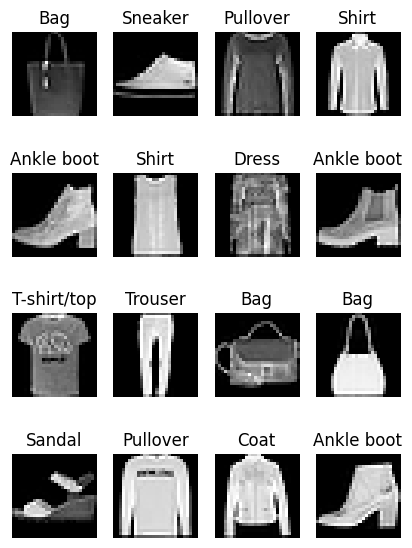

In [129]:
fig = plt.figure(figsize=(5, 7))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data2), size=[1]).item()
  img, label = train_data2[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names2[label])
  plt.axis(False)

In [65]:
train_dataloader2 = DataLoader(dataset=train_data2, batch_size=BATCH_SIZE, shuffle=True)

test_dataloader2 = DataLoader(dataset=test_data2, batch_size=BATCH_SIZE, shuffle=True)

len(train_dataloader2), len(test_dataloader2)

(1875, 313)

In [66]:
len(train_data2) / BATCH_SIZE, len(test_data2) / BATCH_SIZE

(1875.0, 312.5)

In [82]:
class FashionMNIST(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv2_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv2_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv2_block1(x)
        x = self.conv2_block2(x)
        x = self.classifier(x)
        return x

In [69]:
len(class_names2)

10

In [83]:
model_3 = FashionMNIST(input_shape=1, hidden_units=10, output_shape=len(class_names2)).to(device=device)

In [89]:
optimizer2 = torch.optim.SGD(params=model_3.parameters(), lr= 0.1)

In [68]:
img2.shape

torch.Size([1, 28, 28])

In [74]:
torch.manual_seed(42)

random = torch.rand(size=(1, 1, 28, 28))
random = model_3.conv2_block1(random)
print(random.shape)

random = model_3.conv2_block2(random)
print(random.shape)

torch.Size([1, 10, 14, 14])
torch.Size([1, 10, 7, 7])


In [ ]:
len(train_dataloader2), len(test_dataloader2) # number of batches

(1875, 313)

In [127]:
for epoch in range(epochs):
    train_loss, train_acc = 0, 0

    model_3.train()

    for (x, y) in (train_dataloader2):
        x, y = x.to(device), y.to(device)

        train_logits = model_3(x)

        loss = loss_func(train_logits, y)
        train_loss += loss
        train_acc += accuracy_fn(train_logits.argmax(dim=1), y)

        optimizer2.zero_grad()

        loss.backward()

        optimizer2.step()

    train_loss /= len(train_dataloader2)
    train_acc /= len(train_dataloader2)  # train_acc = sum of accuracy of all batches / len(train_dataloader2) is the number of batches
    print(f"train loss = {train_loss}, train accuracy = {train_acc}")


    test_loss, test_acc = 0, 0
    model_3.eval()

    with torch.inference_mode():
        for x, y in test_dataloader2:
            x, y = x.to(device), y.to(device)

            test_logits = model_3(x) # raw logits

            y_test_pred = test_logits.argmax(dim=1)
            test_loss += loss_func(test_logits, y)
            test_acc += accuracy_fn(y_test_pred, y)


        test_loss /= len(test_dataloader2)
        test_acc /= len(test_dataloader2)
        print(f"test loss = {test_loss}, test accuracy = {test_acc}")

train loss = 0.2665599584579468, train accuracy = 90.305
test loss = 0.2871766686439514, test accuracy = 89.71645367412141
train loss = 0.2583625614643097, train accuracy = 90.51666666666667
test loss = 0.3045077323913574, test accuracy = 88.81789137380191
train loss = 0.2524659335613251, train accuracy = 90.79333333333334
test loss = 0.2874753177165985, test accuracy = 89.62659744408946
train loss = 0.24692490696907043, train accuracy = 91.00666666666666
test loss = 0.292549192905426, test accuracy = 89.15734824281151
train loss = 0.24260638654232025, train accuracy = 91.10166666666667
test loss = 0.2983550727367401, test accuracy = 89.39696485623003


In [130]:
wrong_preds = []

model_3.eval()
with torch.inference_mode():
    for X, y in test_dataloader2:
        X, y = X.to(device), y.to(device)

        logits = model_3(X)
        preds = logits.argmax(dim=1)

        for i in range(len(preds)):
            if preds[i] != y[i]:
                wrong_preds.append(
                    (X[i].cpu(), y[i].cpu(), preds[i].cpu())
                )

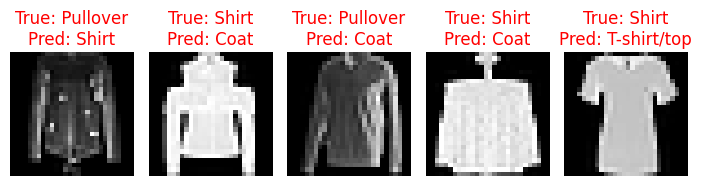

In [131]:
import random

samples = random.sample(wrong_preds, 5)

plt.figure(figsize=(14, 6))

for i, (image, true_label, pred_label) in enumerate(samples):

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    color = "red" if true_label != pred_label else "green"

    plt.title(
        f"True: {class_names2[true_label.item()]}\n"
        f"Pred: {class_names2[pred_label.item()]}",
        color=color
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Most errors seem to come from visually similar classes, such as Shirt and T-shirt/top. However, the model could still be improved to distinguish these classes better.